# TCBench: Quick Start

**Goal.** This notebook demonstrates a minimal, end-to-end workflow to evaluate tropical-cyclone (TC) **track** and **intensity** forecasts on the **2023** test year using the TCBench toolbox and local CSV files.  
It loads IBTrACS, loads one or more model track CSVs, runs the evaluation (or loads the corresponding `*_results.csv` if already computed), and renders compact figures and DataFrame previews so that every step is transparent.

**What you’ll see (at a glance):**
- A quick preview (`.head()`) of **IBTrACS** after light preprocessing (e.g., 6-hour grid, 00/12Z inits).  
- A preview of **model track CSVs** (columns & a few rows).  
- A preview of **evaluation outputs** (columns & a few rows) for both deterministic and probabilistic metrics.  
- Simple plots mirroring the figures in the paper for a minimal subset (to keep runtime short).

> This notebook is **self-contained and runs offline**.

### Add-Your-Own Model (One-Minute Setup)

1. Export your model’s TC track forecasts for **2023** (00/12Z inits; 6-hourly leads up to 120 h).  
2. Save them into the evaluation directory (e.g., `results/<your_model>.csv`), following the conventions described below.  
3. Re-run the **evaluation** cell—your file will be detected automatically, evaluated (or loaded), and included in the previews and plots.


In [2]:
import sys
import subprocess
from pathlib import Path

# Install requirements into the *current* Jupyter kernel 
main_dir = Path.cwd().parent
subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(main_dir / "requirements.txt")])
print("All dependencies have been installed successfully.")

All dependencies have been installed successfully.


#### `Schema for Probabilistic Models`

| SID | Initial Time | Valid Time | ensemble_idx | wind max | pressure min | lat | lon | 
|-----|-------------|------------|:------------:|:--------:|:------------:|:---:|:---:|
| 2023013S08081 | 2023-01-18 12:00:00 | 2023-01-18 18:00:00 | 0 | 41.02 | 998.0 | -13.5 | 51.7 |

---

#### `Schema for Deterministic Models`

| SID | Initial Time | Valid Time | wind max | pressure min | lat | lon |
|-----|-------------|------------|:--------:|:------------:|:---:|:---:|
| 2023005S18142 | 2023-01-09 12:00:00 | 2023-01-10 12:00:00 | 26.03 | 985.65 | -36.75 | 176.5 |

We note that the files can include additional columns that won't be used during processing (e.g., cyclone names, basins)

## Load the IBTrACS test set (ground truth)
**IBTrACS** (International Best Track Archive for Climate Stewardship) is the
global reference archive of tropical cyclone “best tracks,” compiled from all
basin warning centers and harmonized by NOAA. It provides a consistent,
time-ordered record of each storm’s location and intensity through its life
cycle. We use IBTrACS as the **ground truth** for verifying model tracks and
intensities.

The file we load here (`data/ibtracs/ibtracs.ALL.list.v04r01.csv`) contains the
global record; in this notebook we subset to **2023** and verify on the
standard **6-hour grid** (00/06/12/18 UTC) with intensities referenced to the
“USA” source used in IBTrACS.

---

### Columns used in ibtracs

| Column        | Type / Units                 | Description                                                                                             | Notes |
|---            |---                           |---                                                                                                      |---|
| `SID`         | string                       | Unique storm identifier within IBTrACS.                                                                 | Stable key used to group track points belonging to the same cyclone. |
| `SEASON`      | integer (year)               | Season year of the storm.                                                                               | We filter to `SEASON == 2023`. |
| `BASIN`       | categorical                  | Basin code (e.g., `NA` North Atlantic, `WP` West Pacific, `EP` East Pacific, `NI` North Indian, `SI` South Indian, `SP` South Pacific). |  |
| `SUBBASIN`    | categorical / string         | Sub-basin code where available.                                                                         | |
| `NAME`        | string                       | Storm name (if assigned).                                                                               |  |
| `ISO_TIME`    | datetime (UTC, ISO-8601)     | Analysis time for this record.                                                                          | Nominally 6-hourly; occasionally higher frequency. Convert with `pd.to_datetime(..., utc=True)` and floor to the hour if needed. |
| `NATURE`      | categorical                  | Storm nature/class (e.g., `TROPICAL`, `SUBTROPICAL`, `EXTRATROPICAL`, `REMNANT LOW`, `DISTURBANCE`).     | |
| `LAT`         | float (degrees)              | Storm center latitude.                                                                                  |  |
| `LON`         | float (degrees)              | Storm center longitude.                                                                                 |  |
| `USA_ATCF_ID` | string                       | ATCF storm identifier from the USA source (e.g., `AL012023`, `WP192023`).                               |  |
| `USA_WIND`    | float (knots)                | **Maximum 1-minute sustained wind** from the USA source at `ISO_TIME`.                                  | Used as ground-truth intensity for wind. Missing values appear as NaN. |
| `USA_PRES`    | float (hPa)                  | **Minimum central pressure** from the USA source at `ISO_TIME`.                                         | Used as ground-truth intensity for pressure. Missing values appear as NaN. |


In [ ]:
from utils import toolbox

tracks_path = str(Path.cwd() / "data" / "ibtracs")
ibtracs = toolbox.read_hist_track_file(tracks_path=tracks_path)

ibtracs = ibtracs[ibtracs["ISO_TIME"].dt.year == 2023]
ibtracs.sample(5)

/home/mgomezd1/repos/tcbench/requirementstester/lib/python3.12/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,SID,SEASON,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,USA_ATCF_ID,USA_WIND,USA_PRES
710635,2023271N14144,2023,WP,MM,KOINU,2023-10-08 21:00:00,TS,21.703125,113.3750,WP142023,60,988
710598,2023271N14144,2023,WP,MM,KOINU,2023-10-06 00:00:00,TS,21.796875,117.6875,WP142023,90,965
710840,2023281N14260,2023,EP,MM,MAX,2023-10-08 00:00:00,DS,13.796875,260.1250,EP162023,25,1007
707901,2023193N37305,2023,NA,NA,DON,2023-07-24 15:00:00,DS,47.500000,319.1875,AL052023,40,1005
710601,2023271N14144,2023,WP,MM,KOINU,2023-10-06 09:00:00,TS,21.593750,116.6250,WP142023,100,957


### Matching tracks using HuracánPy

This cell runs the track matching pipeline. It assumes that you have a folder named after your model, and that the folder contains files with individual files for each initial time of forecast. Concretely, it:

1) **Loads tracks** previously detected in  model outputs, as well as the tracks from IBTrACS. 
2) **Matches the detected tracks** to known storms using huracanpy.
3) **Builds the a dataframe** by extracting, for each matched storm, the detected track's time series of wind speed, pressure, lat, and lon.
4) **Assembles the CSV** that follows the schema described above, converting the windspeed from m/s to knots and the pressure from pascals to hectopascals (assuming the tracks follow the default units expressed by ERA5 data), naming it \<model\>.csv

Script arguments:

**--model** The models looks for a directory named <model> within the 'data' subdirectory of the current working directory. This directory should contain individual files named: 
>> \<model-tag\>\_YYYY.MM.DD-HHhMMm\_\<any-other-tags\>.csv
where HH and MM represent the hour and minute digits. 

**--ibtracs_path** This path points to the IBTrACS csv you wish to use.

**--eval_dir** This path points to the folder where you want to create the matched tracks csv - the default is \<current_working_dir\>/\<outputs\>


In [ ]:
#Generate PDF plots for all models and metrics

#build the command to run the plotting script
match_command = ["python", str(Path.cwd() / "track_matcher.py"),
                "--model", "2023_pangu",
                "--ibtracs_path", str(Path.cwd() / "data" / "ibtracs" / "ibtracs.ALL.list.v04r01.csv"),
                # "--output_path", str(Path.cwd() / "outputs" / "pangu_test.csv"),
                ]

# Run the plotting script

subprocess.check_call(match_command)
print("Matching script finished.")

Traceback (most recent call last):
  File "/home/mgomezd1/repos/tcbench/dev/track_matcher.py", line 44, in <module>
    ibtracs = pd.read_csv(ibtracs_path, keep_default_na=False)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/mgomezd1/repos/tcbench/requirementstester/lib/python3.12/site-packages/pandas/io/parsers/readers.py", line 1026, in read_csv
    return _read(filepath_or_buffer, kwds)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/mgomezd1/repos/tcbench/requirementstester/lib/python3.12/site-packages/pandas/io/parsers/readers.py", line 620, in _read
    parser = TextFileReader(filepath_or_buffer, **kwds)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/mgomezd1/repos/tcbench/requirementstester/lib/python3.12/site-packages/pandas/io/parsers/readers.py", line 1620, in __init__
    self._engine = self._make_engine(f, self.engine)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/mgomezd1/repos/tcbench/requ

CalledProcessError: Command '['python', '/home/mgomezd1/repos/tcbench/dev/track_matcher.py', '--model', '2023_pangu', '--ibtracs_path', '/home/mgomezd1/repos/tcbench/dev/data/ibtracs/ibtracs.ALL.list.v04r00.csv']' returned non-zero exit status 1.

### Evaluate and materialize results (then preview )

This cell runs the **evaluation pipeline** over all model track CSVs found in `outputs/` and
verifies them against **IBTrACS 2023** (`data/ibtracs`). Concretely, it:

1) **Discovers** candidate input files in `outputs/` (e.g., `2023_PANGU.csv`, `2023_aifs.csv`, …).  
2) **Matches** each track to IBTrACS on the standardized 6-hour grid (00/12Z inits, 6–120 h leads).  
3) **Computes metrics** and writes them to disk as `<name>_results.csv`.  
   - Deterministic: track errors (DPE/Along/Cross), intensity errors (AE/SE), etc.  
   - Probabilistic (if ensemble): CRPS variants are added as `*_mean` / `*_std`.  
4) **Generates/refreshes RI files** (`<name>_RI.csv`) so RI plots can be made later.  
5) Returns a couple of convenience objects:
   - `result_paths`: where each results file was written.  
   - `all_cases`: the evaluated `(SID, Initial Time, Valid Time)` pairs (useful for FAIR/coverage).


**Recompute?** By default `recompute=False`, so existing `<name>_results.csv` files are **reused** and
only **new** inputs are computed. Set `recompute=True` if you want to **overwrite** the results.

Below, we print a small random sample of PANGU’s deterministic metrics and GENC's probabilistic ones to show the result schema.

In [20]:
from evaluate_tracks import evaluate_tracks
import pandas as pd

eval_dir = str(Path.cwd() / "outputs")
ib_dir = str(Path.cwd() / "data" / "ibtracs")

result_paths, result_dfs, all_cases = evaluate_tracks(
    eval_folder=eval_dir,
    ibtracs_tracks_path=ib_dir,
    year=2023,
    select_files=["2023_PANGU.csv"],  # ex: ["2023_PANGU.csv", "2023_GENC.csv"]
    recompute=True,
    only_ri=False,
    exclude_patterns=("RI", "results", "ibtracs"),
    save_results=True,
    return_dataframes=False,
    verbose=True,
)

# Example: preview one model's results
source_file = str(Path(eval_dir) / "2023_PANGU_results.csv")
pangu_results_df = pd.read_csv(source_file)
print("Example: PANGU results (Deterministic metrics)")
pangu_results_df.sample(5)

Candidates in '/home/mgomezd1/repos/tcbench/dev/outputs': 1 | to compute (recompute=True): 1

Working on 2023_PANGU.csv...
Calculating DPE...
Calculating AE...
Calculating SE...
Calculating CARTE...
Overwriting existing results: /home/mgomezd1/repos/tcbench/dev/outputs/2023_PANGU_results.csv
[RI] Recomputing RI file for 2023_PANGU.csv...
Example: PANGU results (Deterministic metrics)


,SID,Initial Time,Valid Time,wind max,pressure min,lat,lon,DPE_GCD,AE_wind,AE_pressure,SE_wind,SE_pressure,Along_TE,Cross_TE,DPE_cart
140,2023013S08081,2023-01-15 12:00:00,2023-01-18 00:00:00,30.229589,1001.5610,-14.50,57.75,216.013123,4.770411,6.5610,22.756822,43.046721,197.916317,45.182899,203.008282
9333,2023290N12256,2023-10-19 12:00:00,2023-10-20 00:00:00,42.219233,987.9856,17.75,251.75,18.454374,62.780767,39.9856,3941.424720,1598.848207,23.382700,5.999119,24.140010
534,2023129N08091,2023-05-07 00:00:00,2023-05-12 00:00:00,39.375201,991.5378,12.75,84.25,424.145817,25.624799,9.5378,656.630346,90.969629,0.000000,403.784250,403.784250
7282,2023251N16334,2023-09-17 00:00:00,2023-09-19 06:00:00,24.767846,1011.8870,38.75,319.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2128,2023193N37305,2023-07-16 12:00:00,2023-07-20 00:00:00,23.745386,1010.4880,32.00,317.00,302.565885,21.254614,9.4880,451.758628,90.022144,63.516585,378.115734,383.413439


In [ ]:
print("Example: GENC results (Probabilistic metrics)")
genc_results_df = pd.read_csv(os.path.join(eval_dir, "2023_GENC_results.csv"))
genc_results_df.sample(5)

,SID,Initial Time,Valid Time,lat,lon,wind max,pressure min,Hour,DPE_GCD_mean,DPE_GCD_std,...,DPE_cart_mean,Along_TE_std,Cross_TE_std,DPE_cart_std,CRPS_vmax_mean,CRPS_pmin_mean,CRPS_vmax_std,CRPS_pmin_std,CRPS_haversine_mean,CRPS_haversine_std
841,2023138N05151,2023-05-21 12:00:00,2023-06-01 18:00:00,26.13,125.00,73.5,979.0,270.0,1030.154593,817.539239,...,725.300492,40.104072,536.326828,532.699283,18.028475,2.098785,NaN,NaN,436.066127,NaN
732,2023138N05151,2023-05-20 12:00:00,2023-05-29 12:00:00,22.50,127.00,59.9,989.2,216.0,420.024339,276.763046,...,516.540741,18.374682,361.430420,359.368651,7.574041,3.499837,NaN,NaN,198.423342,NaN
1975,2023156N10067,2023-06-15 12:00:00,2023-06-16 18:00:00,24.63,70.37,69.9,981.7,30.0,49.298770,24.334450,...,48.099310,14.601566,26.555431,24.457181,30.590531,2.291102,NaN,NaN,28.510664,NaN
7527,2023251N16334,2023-09-16 12:00:00,2023-09-17 00:00:00,34.00,320.00,42.0,1001.0,12.0,29.038853,14.110134,...,51.407997,16.396466,34.743562,37.811782,0.615429,2.064980,NaN,NaN,15.856212,NaN
9066,2023271N14144,2023-10-07 00:00:00,2023-10-09 00:00:00,21.00,115.50,27.8,1008.8,48.0,91.328956,44.412196,...,87.145803,7.611258,48.105354,44.248628,14.873939,10.940404,NaN,NaN,46.147075,NaN


In [7]:
#Generate PDF plots for all models and metrics

#build the command to run the plotting script
plot_command = ["python", str(Path.cwd() / "plot_errors.py"),
                "--eval_dir", str(Path.cwd() / "outputs"),
                "--ibtracs_path", str(Path.cwd() / "data" / "ibtracs")]

# Run the plotting script

subprocess.check_call(plot_command)
print("Plots script finished.")

/home/mgomezd1/repos/tcbench/requirementstester/lib/python3.12/site-packages/numcodecs/__init__.py:106: DeprecationWarning: crc32c usage is deprecated since numcodecs v0.16.4. It is recommended to install google_crc32c instead.
  from numcodecs.checksum32 import CRC32, Adler32, JenkinsLookup3


Figure(1600x1230)
Figure(1400x1250)
Figure(1000x500)
Figure(640x480)
Figure(1560x900)
Figure(1560x900)
Figure(1200x600)
Figure(1200x500)
Plots script finished.


/home/mgomezd1/repos/tcbench/requirementstester/lib/python3.12/site-packages/numcodecs/__init__.py:106: DeprecationWarning: crc32c usage is deprecated since numcodecs v0.16.4. It is recommended to install google_crc32c instead.
  from numcodecs.checksum32 import CRC32, Adler32, JenkinsLookup3


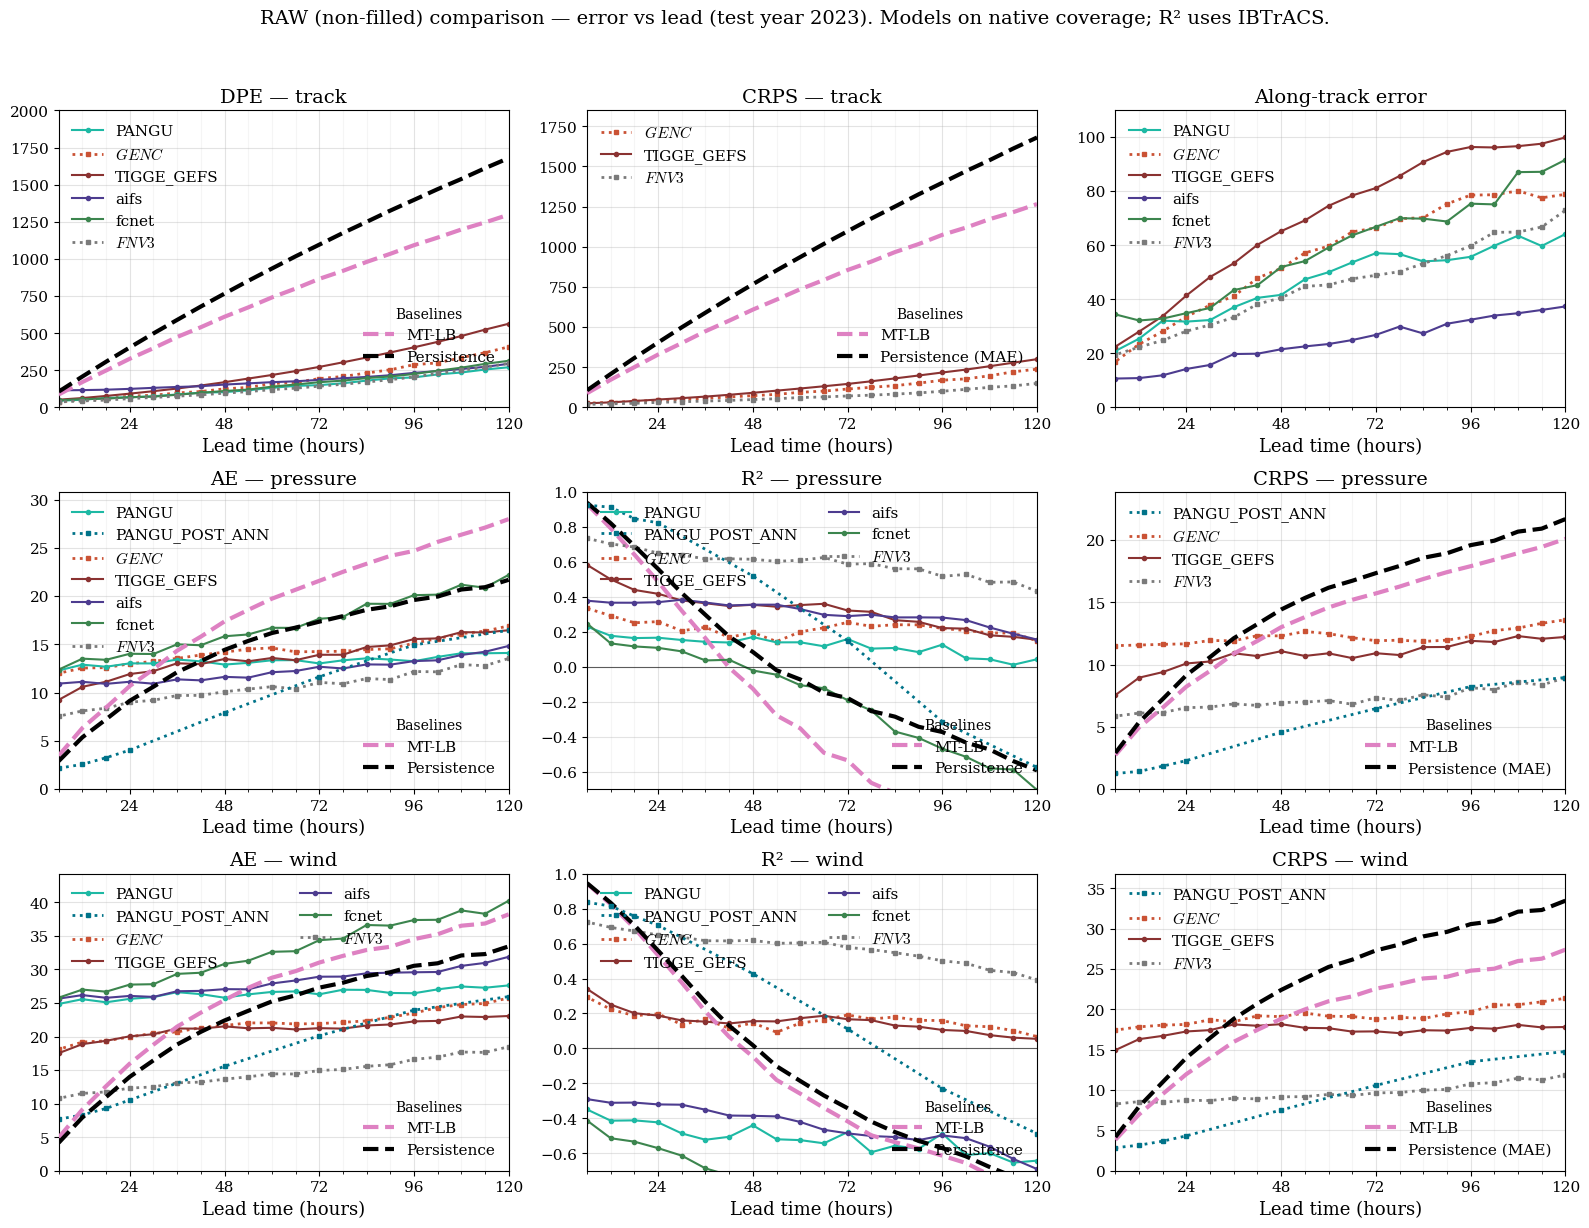

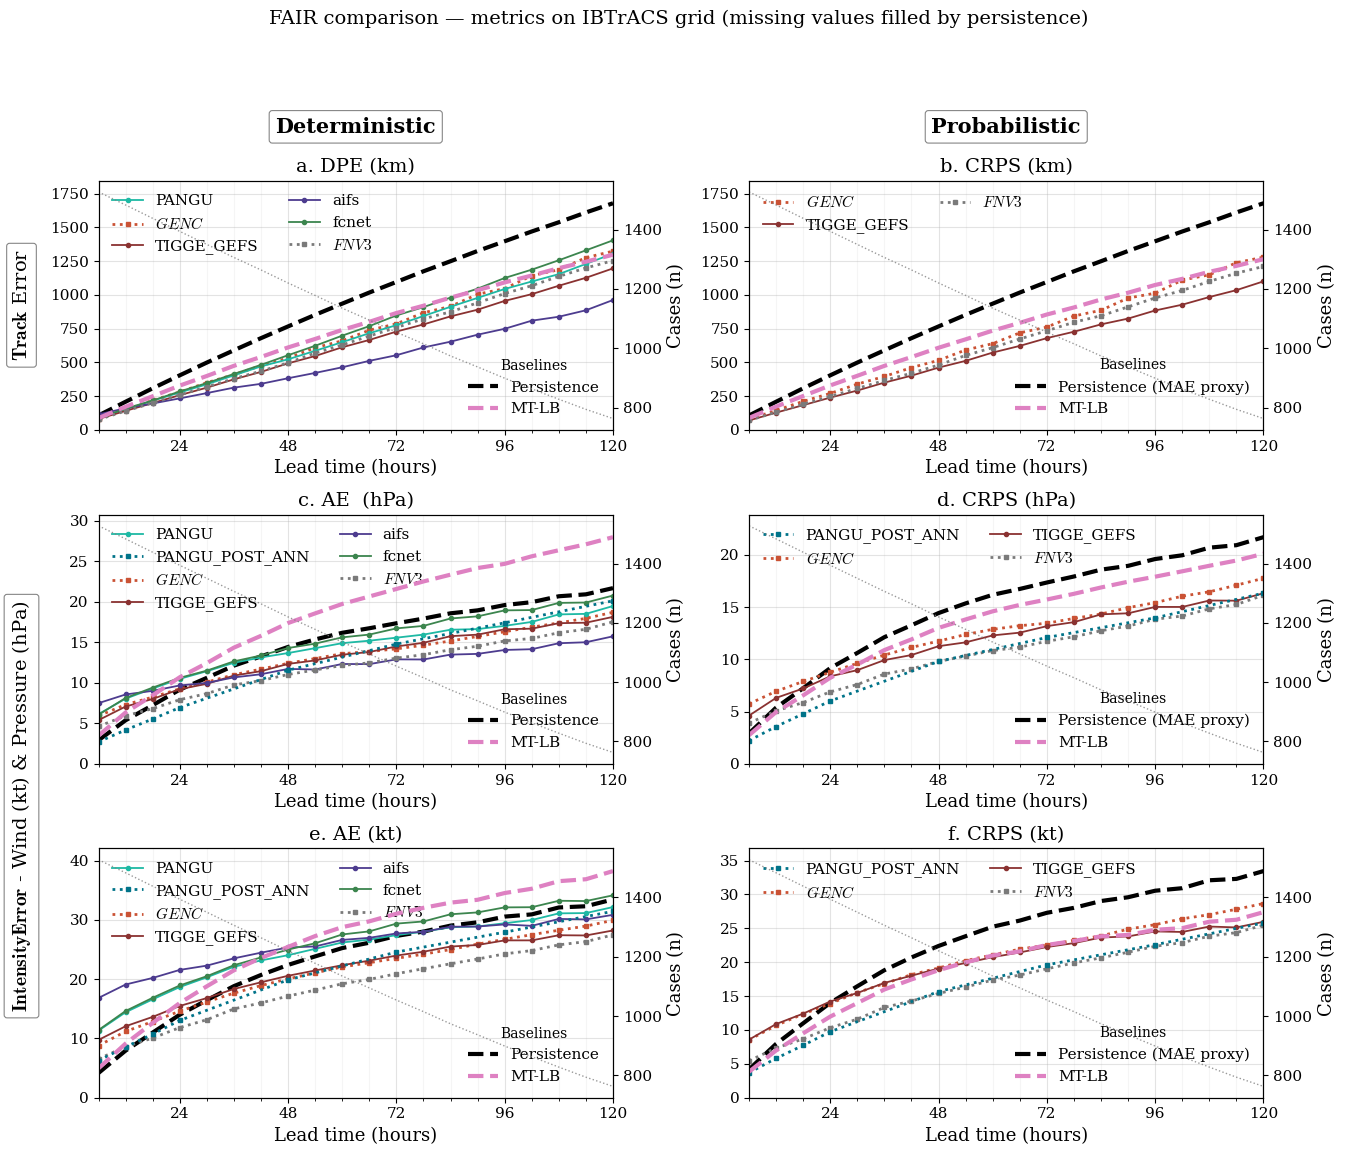

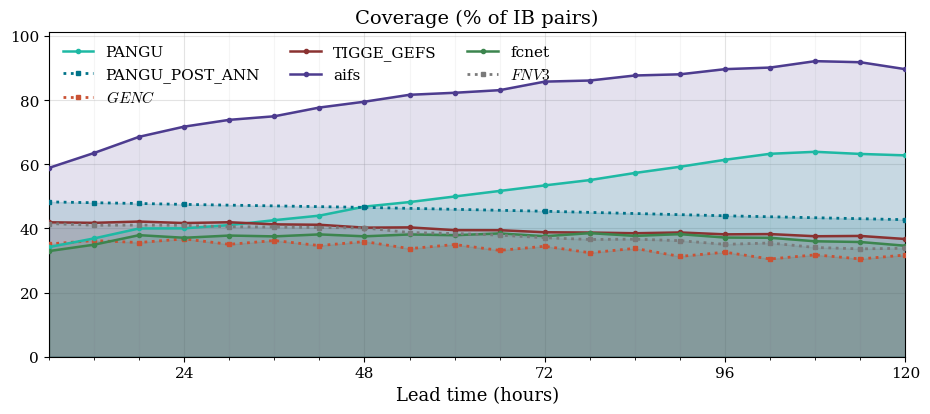

<Figure size 640x480 with 0 Axes>

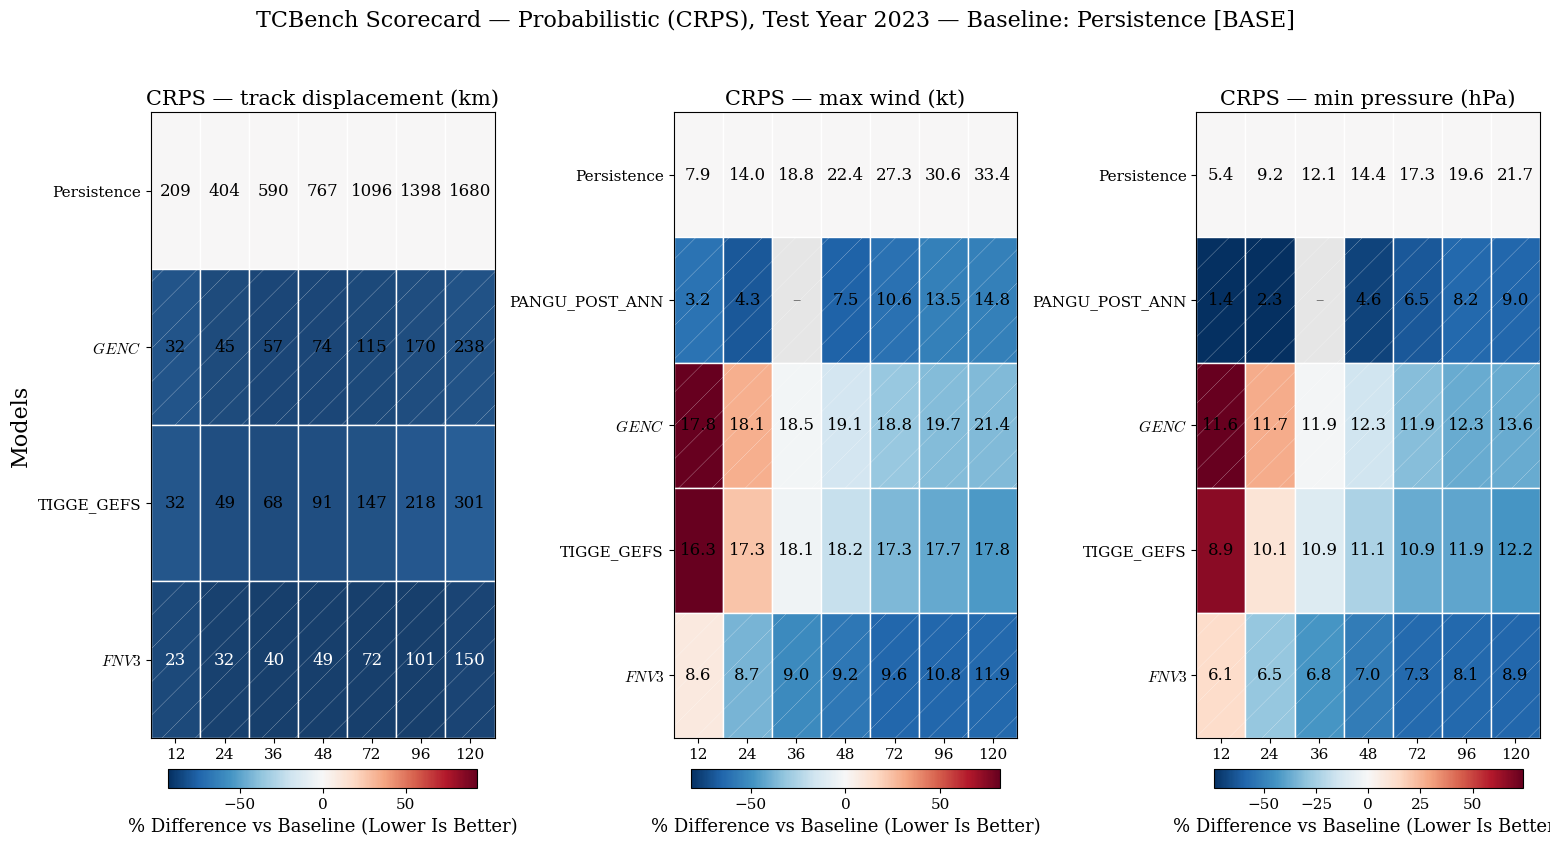

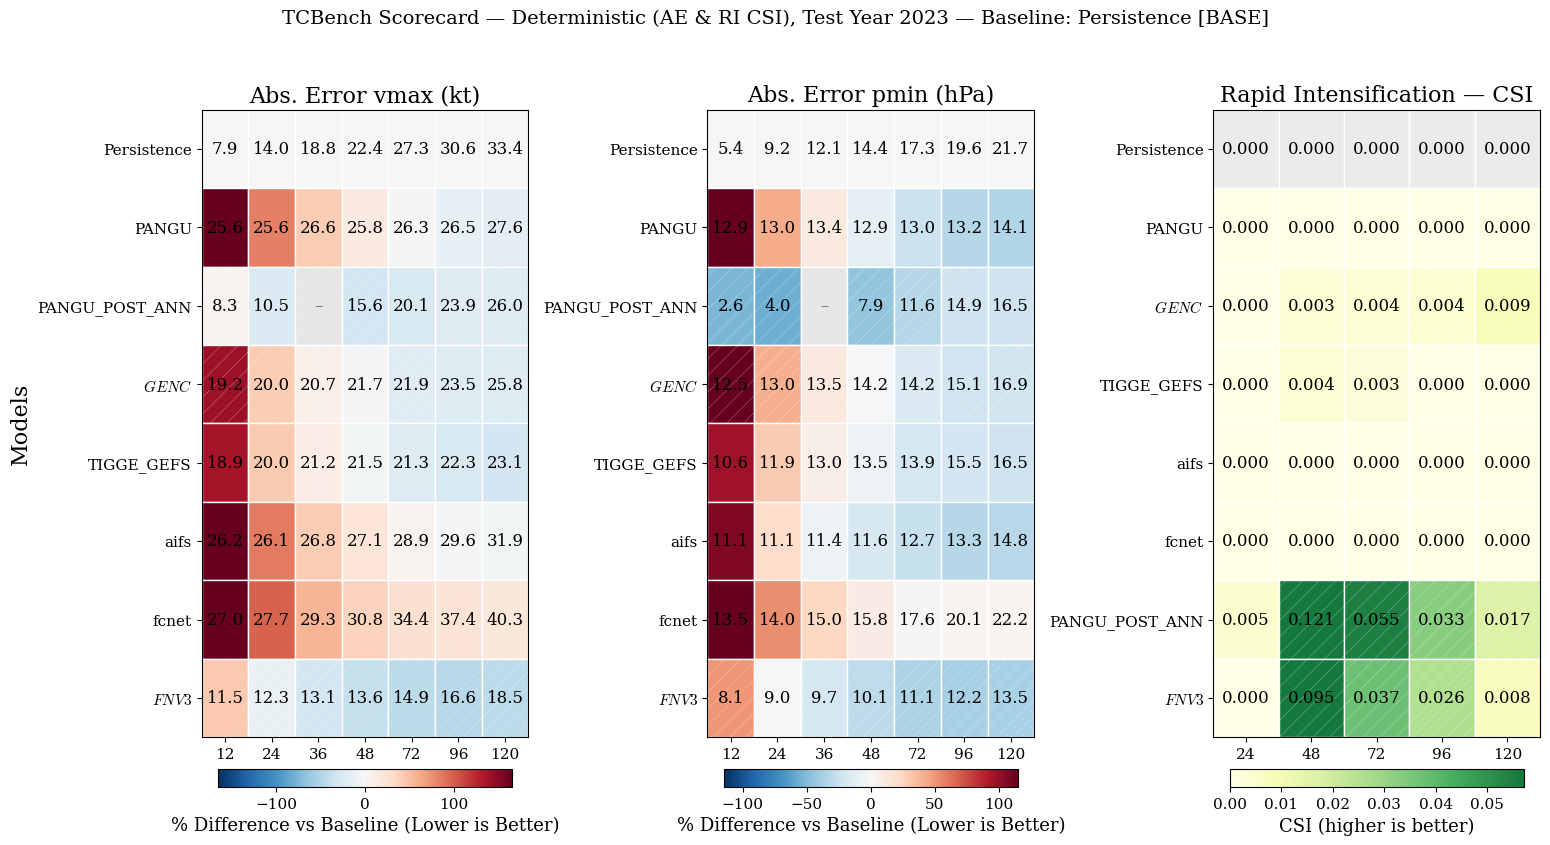

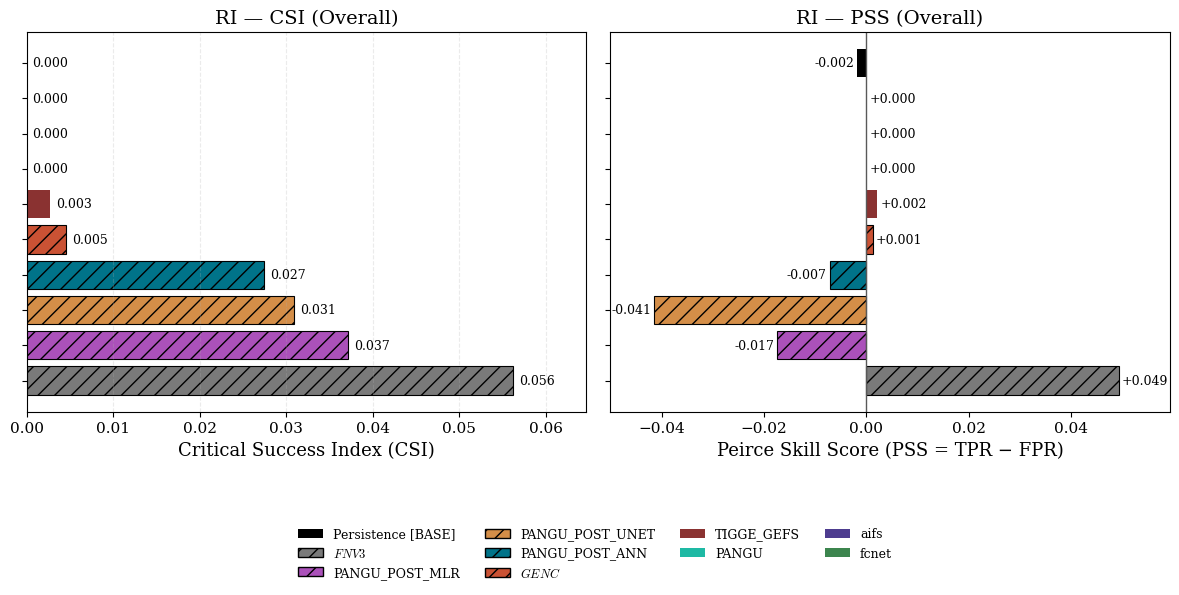

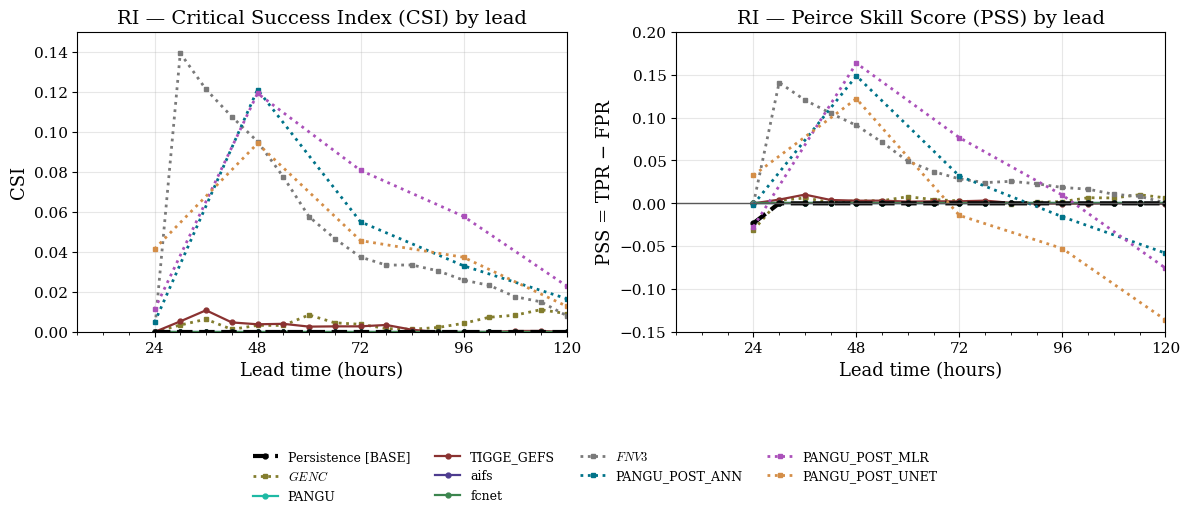

In [8]:
# Alternatively, use magic commands to also display the generated plots in the notebook
%run -i plot_errors.py \
    --eval_dir "./outputs" \
    --ibtracs_path "./data/ibtracs"